In [1]:
## 该 notebook 不运行训练，只加载训练好的 theta 主线模型做评估\n## 当前维护的代码路径：src/theta 和 src/common\n## 建议顺序：先设置项目根目录，再导入当前主线模块，然后读取某个 run_dir 的 config 与 checkpoint，最后复现 test split 并输出评估图。

In [2]:
# Step 1. 设置项目根目录，并把仓库根目录加入 sys.path
import os
import sys

PROJECT_ROOT = "/home/server/projects/energy_reconstruction"
os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("cwd:", os.getcwd())
print("python path ok:", PROJECT_ROOT in sys.path)

cwd: /home/server/projects/energy_reconstruction
python path ok: True


In [3]:
# Step 2. 导入当前维护主线需要的模块
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from src.theta.ParticleDataset_theta import ParticleDataset
from src.theta.ParticleRegressor_theta import ParticleNetRegressor
from src.theta.evaluate_theta import evaluate_model
from src.common import utils

In [4]:
# Step 3. 定义评估函数：读取 run_dir/config.json 和 best_model.pt，重建 test split 后执行评估
import os
import json
import numpy as np
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

def main(run_dir):
    config_path = os.path.join(run_dir, "config.json")
    ckpt_path = os.path.join(run_dir, "checkpoints", "best_model.pt")

    with open(config_path, "r") as f:
        args = json.load(f)

    print(f"📦 使用配置: {config_path}")
    print(f"📦 加载模型: {ckpt_path}")

    utils.check_gpu_status()

    # ===== ROOT 文件 =====
    root_path = args["root_path"]
    files = sorted(os.listdir(root_path))
    files = [os.path.join(root_path, f) for f in files]
    root_files = files[: args["n_files"]]

    # ===== 保持和训练一致的 test split =====
    train_files, test_files = train_test_split(
        root_files,
        test_size=args["test_size"],
        random_state=args["seed"]
    )

    # ===== cuts =====
    cuts = dict(
        Emin=args["Emin"],
        Emax=args["Emax"],
        pinc_max=args["pinc_max"],
        dcedge_min=args["dcedge_min"],
        dangle_max_rad=args["dangle_max_deg"] * np.pi / 180.0,
        theta_max_rad=args["theta_max_deg"] * np.pi / 180.0,
        use_core_box=args["use_core_box"],
        core_box=tuple(args["core_box"]),
        vqsamp_ratio_min=args["vqsamp_ratio_min"],
    )

    # ===== dataset =====
    processing_conditions = [
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
    ]

    test_dataset = ParticleDataset(
        root_files=test_files,
        branches=["vx", "vy", "vt", "vq"],
        target_branch=["mc_energy"],
        processing_conditions=processing_conditions,
        max_points=args["max_points"],
        cuts=cuts,
        norm_mode=args["norm_mode"],
        sample_mode=args["sample_mode"],
        io_workers=args["io_workers"],
        compute_scaler=False,
        seed=args["seed"],
        verbose=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=args["batch_size"],
        shuffle=False,
        num_workers=args["num_workers"],
        pin_memory=args["pin_memory"]
    )

    # ===== model =====
    model = ParticleNetRegressor(
        input_dims=2,
        conv_params=[
            (16, (64, 64, 64)),
            (16, (128, 128, 128)),
            (16, (256, 256, 256))
        ],
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True,
        theta_embed_dim=args["theta_embed_dim"],
        theta_embed_dropout=args["theta_embed_dropout"],
    )

    # ===== 评估 =====
    out_dir = os.path.join(run_dir, "fig_eval_only")
    os.makedirs(out_dir, exist_ok=True)

    evaluate_model(
        model,
        test_loader,
        checkpoint_path=ckpt_path,
        out_dir=out_dir,
        space=args["eval_space"],
        save_arrays=True,
    )

    print("✅ 评估完成")
    print(f"📊 图像输出: {out_dir}")

In [19]:
# Step 4. 常用 run 备注
# theta_embed_2707 是标准 theta embed
# theta_embed_2709 是 1-100 TeV 版本
# ture_in_pred_2700 是无 theta embed 结果

In [5]:
# Step 5. 选择一个 run_dir 并运行评估
run_dir = "/home/server/projects/energy_reconstruction/runs/theta_embed_2709"
main(run_dir)

📦 使用配置: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/config.json
📦 加载模型: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/checkpoints/best_model.pt
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
使用设备: cuda


/home/server/projects/energy_reconstruction/src/theta/evaluate_theta.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_locati

✅ 成功加载模型权重: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/checkpoints/best_model.pt

=== 模型评估结果（overall）===
[log][unweighted]   bias=0.0374, sigma=0.1201, rmse=0.1258
[log][mc_weighted] bias=0.0413, sigma=0.1186, rmse=0.1256
[lin][unweighted]  rel_bias=0.1326, rel_sigma=0.3265
[lin][mc_weighted] rel_bias=0.1418, rel_sigma=0.3261
[log]             R²=0.9043
✅ Resolution 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/resolution_20260307_233207.png
✅ Energy response heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/pred_vs_true_heatmap_20260307_233207.png
✅ Bias 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/bias_20260307_233208.png
✅ log RMS error 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/logRMS_20260307_233208.png
✅ 以预测能量分bin的分布图已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_270

In [6]:
# 画plot_pred_vs_logdiff_heatmap

In [3]:
def plot_pred_vs_logdiff_heatmap(
    true,
    pred,
    weights=None,
    bins=(120, 120),
    diff_range=None,
    save_name=None,
    out_dir=None,
    space="log",
):
    """
    绘制 log10(E_pred) vs [log10(E_pred) - log10(E_true)] 的二维热图

    Parameters
    ----------
    true, pred : array-like
        log10(E / GeV)
    weights : array-like or None
        事件权重（如 mc_weight）
    bins : int or tuple
        2D histogram 的 bin 数
        - int: x/y 都用同样 bin 数
        - tuple: (xbins, ybins)
    diff_range : tuple or None
        y 轴范围，例如 (-1.5, 1.5)
        若为 None，则自动取数据范围
    save_name : str or None
        保存文件名
    out_dir : str or None
        输出目录
    space : str
        目前仅支持 "log"
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm

    true = np.asarray(true).squeeze()
    pred = np.asarray(pred).squeeze()

    if weights is not None:
        weights = np.asarray(weights).squeeze()

    if space != "log":
        raise ValueError(
            "plot_pred_vs_logdiff_heatmap is implemented for log space only."
        )

    # ========= valid mask =========
    if weights is None:
        m = np.isfinite(true) & np.isfinite(pred)
    else:
        m = (
            np.isfinite(true)
            & np.isfinite(pred)
            & np.isfinite(weights)
            & (weights > 0)
        )

    true = true[m]
    pred = pred[m]
    if weights is not None:
        weights = weights[m]

    # ========= define x and y =========
    x = pred
    y = pred - true   # ΔlogE

    # ========= bin settings =========
    if isinstance(bins, int):
        xbins = bins
        ybins = bins
    else:
        xbins, ybins = bins

    if diff_range is None:
        ylo = np.nanpercentile(y, 0.5)
        yhi = np.nanpercentile(y, 99.5)
        pad = 0.05 * (yhi - ylo)
        y_range = (ylo - pad, yhi + pad)
    else:
        y_range = diff_range

    x_range = (np.nanmin(x), np.nanmax(x))

    # ========= 2D histogram =========
    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=[xbins, ybins],
        range=[x_range, y_range],
        weights=weights,
    )

    H_plot = H.copy()
    H_plot[H_plot <= 0] = np.nan

    # ========= plot =========
    plt.figure(figsize=(6.5, 6))
    im = plt.pcolormesh(
        xedges,
        yedges,
        H_plot.T,
        norm=LogNorm(vmin=np.nanmin(H_plot), vmax=np.nanmax(H_plot)),
        cmap="viridis",
        shading="auto",
    )

    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)

    plt.xlabel(r"log$_{10}$(E$_{\mathrm{pred}}$ / GeV)")
    plt.ylabel(
        r"log$_{10}$(E$_{\mathrm{pred}}$ / GeV) - log$_{10}$(E$_{\mathrm{true}}$ / GeV)"
    )

    if weights is None:
        plt.title(r"logE$_{\mathrm{pred}}$ vs $\Delta$logE (counts)")
        cbar_label = "Counts"
        prefix = "pred_vs_logdiff_heatmap"
    else:
        plt.title(r"logE$_{\mathrm{pred}}$ vs $\Delta$logE (mc-weighted)")
        cbar_label = "Weighted counts"
        prefix = "pred_vs_logdiff_heatmap_weighted"

    cbar = plt.colorbar(im)
    cbar.set_label(cbar_label)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_path = _resolve_save_path(
        out_dir,
        save_name,
        prefix=prefix,
    )
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"✅ Pred vs log-diff heatmap 已保存到: {save_path}")


def plot_true_vs_logdiff_heatmap(
    true,
    pred,
    weights=None,
    bins=(120, 120),
    diff_range=None,
    save_name=None,
    out_dir=None,
    space="log",
):
    """
    绘制 log10(E_true) vs [log10(E_pred) - log10(E_true)] 的二维热图

    Parameters
    ----------
    true, pred : array-like
        log10(E / GeV)
    weights : array-like or None
        事件权重（如 mc_weight）
    bins : int or tuple
        2D histogram 的 bin 数
        - int: x/y 都用同样 bin 数
        - tuple: (xbins, ybins)
    diff_range : tuple or None
        y 轴范围，例如 (-1.5, 1.5)
        若为 None，则自动取数据范围
    save_name : str or None
        保存文件名
    out_dir : str or None
        输出目录
    space : str
        目前仅支持 "log"
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm

    true = np.asarray(true).squeeze()
    pred = np.asarray(pred).squeeze()

    if weights is not None:
        weights = np.asarray(weights).squeeze()

    if space != "log":
        raise ValueError(
            "plot_pred_vs_logdiff_heatmap is implemented for log space only."
        )

    # ========= valid mask =========
    if weights is None:
        m = np.isfinite(true) & np.isfinite(pred)
    else:
        m = (
            np.isfinite(true)
            & np.isfinite(pred)
            & np.isfinite(weights)
            & (weights > 0)
        )

    true = true[m]
    pred = pred[m]
    if weights is not None:
        weights = weights[m]

    # ========= define x and y =========
    x = true  # 横坐标：logE_true
    y = pred - true  # 纵坐标：logE_pred - logE_true

    # ========= bin settings =========
    if isinstance(bins, int):
        xbins = bins
        ybins = bins
    else:
        xbins, ybins = bins

    if diff_range is None:
        ylo = np.nanpercentile(y, 0.5)
        yhi = np.nanpercentile(y, 99.5)
        pad = 0.05 * (yhi - ylo)
        y_range = (ylo - pad, yhi + pad)
    else:
        y_range = diff_range

    x_range = (np.nanmin(x), np.nanmax(x))

    # ========= 2D histogram =========
    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=[xbins, ybins],
        range=[x_range, y_range],
        weights=weights,
    )

    H_plot = H.copy()
    H_plot[H_plot <= 0] = np.nan

    # ========= plot =========
    plt.figure(figsize=(6.5, 6))
    im = plt.pcolormesh(
        xedges,
        yedges,
        H_plot.T,
        norm=LogNorm(vmin=np.nanmin(H_plot), vmax=np.nanmax(H_plot)),
        cmap="viridis",
        shading="auto",
    )

    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)

    plt.xlabel(r"log$_{10}$(E$_{\mathrm{true}}$ / GeV)")  # x-axis: logE_true
    plt.ylabel(r"log$_{10}$(E$_{\mathrm{pred}}$ / GeV) - log$_{10}$(E$_{\mathrm{true}}$ / GeV)")  # y-axis: logE_pred - logE_true

    if weights is None:
        plt.title(r"logE$_{\mathrm{true}}$ vs $\Delta$logE (counts)")
        cbar_label = "Counts"
        prefix = "pred_vs_logdiff_heatmap"
    else:
        plt.title(r"logE$_{\mathrm{true}}$ vs $\Delta$logE (mc-weighted)")
        cbar_label = "Weighted counts"
        prefix = "true_vs_logdiff_heatmap_weighted"

    cbar = plt.colorbar(im)
    cbar.set_label(cbar_label)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_path = _resolve_save_path(
        out_dir,
        save_name,
        prefix=prefix,
    )
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"✅ True vs log-diff heatmap 已保存到: {save_path}")


import os
from datetime import datetime
_DEFAULT_FIG_DIR = "/home/server/projects/energy_reconstruction/fig/"
def _resolve_save_path(out_dir, save_name, prefix):
    save_dir = out_dir if out_dir is not None else _DEFAULT_FIG_DIR
    os.makedirs(save_dir, exist_ok=True)

    if save_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_name = f"{prefix}_{timestamp}.png"

    return os.path.join(save_dir, save_name)

In [20]:
# 读取pred.npz数据，不用再次运行evaluate
import numpy as np
data = np.load("/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig/preds.npz")
print(data.files)

['logE_pred', 'logE_true', 'E_pred', 'E_true', 'rel', 'dlogE', 'mc_weight']


In [22]:
logE_true = data["logE_true"]
logE_pred = data["logE_pred"]
mc_weight = data["mc_weight"]

# 先跑heatmap测试结果
utils.plot_pred_vs_true_heatmap(
    true=logE_true,
    pred=logE_pred,
    weights=mc_weight,
    bins=120,
    out_dir="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only",
    space="log",
)

✅ Energy response heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/pred_vs_true_heatmap_weighted_20260308_001308.png


In [23]:
plot_pred_vs_logdiff_heatmap(
    true=logE_true,
    pred=logE_pred,
    weights=mc_weight,
    bins=(120, 100),
    diff_range=(-1.2, 1.2),
    out_dir="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only",
    space="log",
)

✅ Pred vs log-diff heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/pred_vs_logdiff_heatmap_weighted_20260308_001317.png


In [24]:
plot_true_vs_logdiff_heatmap(
    true=logE_true,
    pred=logE_pred,
    weights=mc_weight,
    bins=(120, 100),
    diff_range=(-1.2, 1.2),
    out_dir="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only",
    save_name="true_vs_logdiff_by_true.png",
    space="log",
)

✅ True vs log-diff heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/true_vs_logdiff_by_true.png


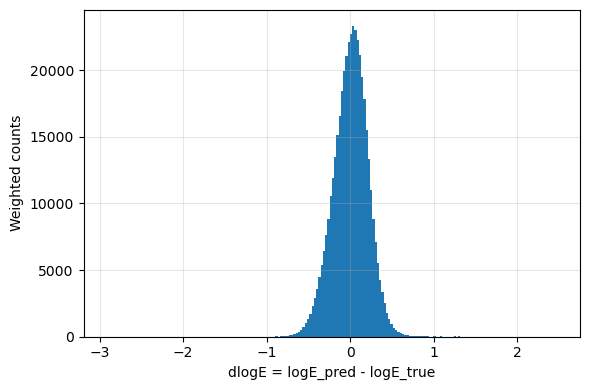

In [ ]:
# sanity check 图
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data["dlogE"], bins=200, weights=mc_weight)
plt.xlabel("dlogE = logE_pred - logE_true")
plt.ylabel("Weighted counts")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 这是dlogE = logE_pred - logE_true的hist，整体偏向高斯对称分布
# 但是有一点偏高（>0), 说明bias偏大

In [3]:
def plot_true_energy_slices_by_pred(
    logE_pred,
    logE_true,
    weights=None,
    pred_range=(3.0, 5.0),
    pred_step=0.2,
    true_bins=120,
    density=False,
    out_path=None,
):
    """
    按 logE_pred 分 bin，画每个 bin 内 logE_true 的分布

    Parameters
    ----------
    logE_pred : array
        log10(E_pred / GeV)

    logE_true : array
        log10(E_true / GeV)

    weights : array or None
        mc_weight

    pred_range : tuple
        logE_pred 的范围 (min, max)

    pred_step : float
        logE_pred 的 bin 宽度

    true_bins : int
        logE_true 分布的 histogram bin 数

    density : bool
        是否归一化为概率密度

    out_path : str
        保存路径
    """

    import numpy as np
    import matplotlib.pyplot as plt

    logE_pred = np.asarray(logE_pred)
    logE_true = np.asarray(logE_true)

    if weights is not None:
        weights = np.asarray(weights)

    # pred energy bins
    edges = np.arange(pred_range[0], pred_range[1] + pred_step, pred_step)

    plt.figure(figsize=(7,5))

    colors = plt.cm.viridis(np.linspace(0,1,len(edges)-1))

    for i in range(len(edges)-1):

        lo = edges[i]
        hi = edges[i+1]

        mask = (logE_pred >= lo) & (logE_pred < hi)

        if np.sum(mask) < 20:
            continue

        data = logE_true[mask]

        if weights is not None:
            w = weights[mask]
        else:
            w = None

        hist, bins = np.histogram(
            data,
            bins=true_bins,
            weights=w,
            density=density
        )

        centers = 0.5*(bins[:-1] + bins[1:])

        plt.plot(
            centers,
            hist,
            lw=2,
            color=colors[i],
            label=f"{lo:.1f} – {hi:.1f}"
        )

    plt.xlabel(r"log$_{10}(E_{true}$/GeV)")
    plt.ylabel("Probability density" if density else "Counts")

    plt.legend(
        title=r"log$_{10}(E_{pred}$/GeV)",
        fontsize=9
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300)

    plt.show()

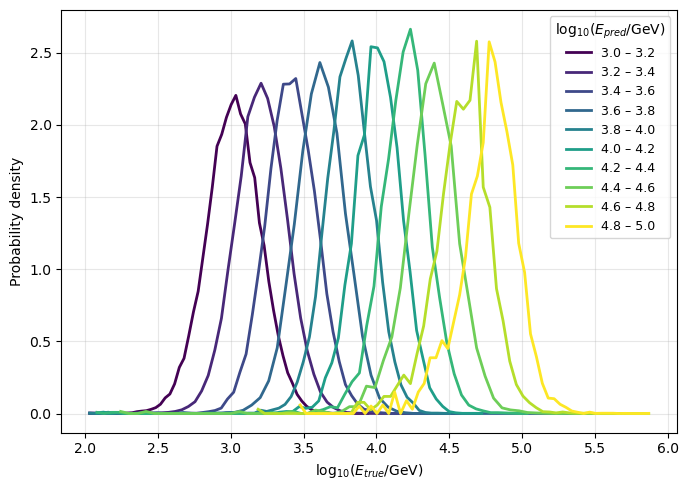

In [5]:
import numpy as np
# 2700 无theta版本
data = np.load("/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig/preds.npz")
logE_true = data["logE_true"]
logE_pred = data["logE_pred"]
mc_weight = data["mc_weight"]
dlogE = data["dlogE"]

plot_true_energy_slices_by_pred(
    logE_pred,
    logE_true,
    weights=mc_weight,
    pred_range=(3,5),
    pred_step=0.2,
    true_bins=60,
    density=True
)

In [8]:
# 标准画法
def plot_energy_migration_slices(
    logE_pred,
    logE_true=None,
    E_true=None,
    weights=None,
    pred_edges=None,
    pred_range=(3.0, 5.0),
    pred_step=0.2,
    true_energy_unit="GeV",
    true_bins=80,
    true_range=None,
    density=True,
    min_events=20,
    smooth=False,
    linewidth=2.0,
    alpha=1.0,
    cmap_name="viridis",
    title=None,
    out_path=None,
):
    """
    标准 energy migration slice 图：
    对若干 logE_pred bin，画对应的 E_true 分布。

    Parameters
    ----------
    logE_pred : array-like
        log10(E_pred / GeV)

    logE_true : array-like or None
        log10(E_true / GeV)

    E_true : array-like or None
        线性能量真值。如果不给，则由 logE_true 计算得到：
        E_true = 10**logE_true

    weights : array-like or None
        事件权重，例如 mc_weight

    pred_edges : array-like or None
        logE_pred 的分 bin 边界。
        若为 None，则由 pred_range 和 pred_step 生成。

    pred_range : tuple
        当 pred_edges=None 时使用，logE_pred 的范围

    pred_step : float
        当 pred_edges=None 时使用，logE_pred 的 bin 宽度

    true_energy_unit : str
        横轴单位标签，仅用于显示，例如 "GeV" 或 "TeV"

    true_bins : int
        E_true 直方图 bin 数（在 logspace 中均匀分 bin）

    true_range : tuple or None
        E_true 的范围（线性能量范围），例如 (1e2, 1e6)
        若为 None，则自动由数据决定

    density : bool
        True -> 画概率密度
        False -> 画 counts / weighted counts

    min_events : int
        每个 pred bin 至少包含多少事件才画

    smooth : bool
        是否做简单平滑（3 点卷积）

    linewidth : float
        线宽

    alpha : float
        透明度

    cmap_name : str
        matplotlib colormap 名称

    title : str or None
        图标题

    out_path : str or None
        保存路径
    """
    import numpy as np
    import matplotlib.pyplot as plt

    logE_pred = np.asarray(logE_pred).squeeze()

    if E_true is None:
        if logE_true is None:
            raise ValueError("需要提供 logE_true 或 E_true 其中之一。")
        logE_true = np.asarray(logE_true).squeeze()
        E_true = 10 ** logE_true
    else:
        E_true = np.asarray(E_true).squeeze()

    if weights is not None:
        weights = np.asarray(weights).squeeze()

    # -------- valid mask --------
    if weights is None:
        m = np.isfinite(logE_pred) & np.isfinite(E_true) & (E_true > 0)
    else:
        m = (
            np.isfinite(logE_pred)
            & np.isfinite(E_true)
            & np.isfinite(weights)
            & (E_true > 0)
            & (weights > 0)
        )

    logE_pred = logE_pred[m]
    E_true = E_true[m]
    if weights is not None:
        weights = weights[m]

    # -------- pred bin edges --------
    if pred_edges is None:
        pred_edges = np.arange(pred_range[0], pred_range[1] + pred_step, pred_step)
    pred_edges = np.asarray(pred_edges)

    # -------- true-energy histogram edges (log-spaced) --------
    if true_range is None:
        e_min = np.nanmin(E_true)
        e_max = np.nanmax(E_true)
        # 稍微收一下，避免极端点把范围拉太开
        e_min = max(e_min, np.nanpercentile(E_true, 0.1))
        e_max = min(e_max, np.nanpercentile(E_true, 99.9))
    else:
        e_min, e_max = true_range

    if e_min <= 0 or e_max <= e_min:
        raise ValueError("true_range 非法，必须满足 0 < e_min < e_max")

    true_edges = np.logspace(np.log10(e_min), np.log10(e_max), true_bins + 1)
    true_centers = np.sqrt(true_edges[:-1] * true_edges[1:])  # log bin center

    # -------- plot --------
    plt.figure(figsize=(7.2, 5.2))
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.08, 0.95, len(pred_edges) - 1))

    n_drawn = 0

    for i in range(len(pred_edges) - 1):
        lo = pred_edges[i]
        hi = pred_edges[i + 1]

        sel = (logE_pred >= lo) & (logE_pred < hi)
        if np.sum(sel) < min_events:
            continue

        e_slice = E_true[sel]
        w_slice = None if weights is None else weights[sel]

        hist, edges = np.histogram(
            e_slice,
            bins=true_edges,
            weights=w_slice,
            density=density,
        )

        if smooth:
            # 简单 3 点平滑，不改横轴
            kernel = np.array([1, 2, 1], dtype=float)
            kernel /= kernel.sum()
            hist = np.convolve(hist, kernel, mode="same")

        label = rf"${lo:.1f}\leq \log_{{10}}(E_{{\rm pred}}/{true_energy_unit}) < {hi:.1f}$"

        plt.plot(
            true_centers,
            hist,
            color=colors[i],
            lw=linewidth,
            alpha=alpha,
            label=label,
        )
        n_drawn += 1

    plt.xscale("log")
    plt.xlabel(rf"$E_{{\rm true}}$ ({true_energy_unit})")
    plt.ylabel("Probability density" if density else "Counts")

    if title is None:
        if density:
            title = r"Energy migration slices: $P(E_{\rm true}\mid E_{\rm pred})$"
        else:
            title = r"Energy migration slices (counts)"
    plt.title(title)

    plt.grid(alpha=0.3, which="both")
    if n_drawn > 0:
        plt.legend(fontsize=9, frameon=False)
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"✅ 已保存到: {out_path}")

    plt.show()

✅ 已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/energy_migration_slices.png


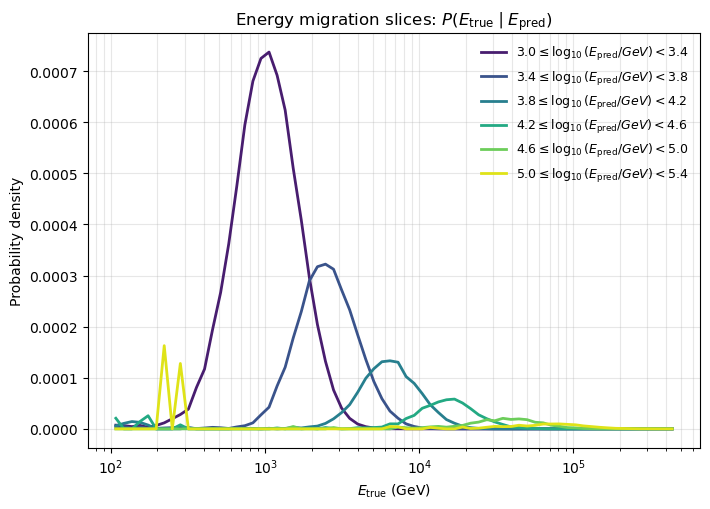

In [2]:
import numpy as np

data = np.load("/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig/preds.npz")

plot_energy_migration_slices(
    logE_pred=data["logE_pred"],
    logE_true=data["logE_true"],
    weights=data["mc_weight"],
    pred_range=(3.0, 5.0),
    pred_step=0.4,     # 建议别太密，0.4 或 0.5 更清楚
    true_bins=70,
    density=True,
    smooth=False,
    out_path="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/energy_migration_slices.png",
)

In [9]:
# 画能量分辨率曲线
def plot_resolution_vs_pred_energy(
    logE_pred,
    logE_true,
    weights=None,
    pred_range=(3.0, 5.0),
    pred_step=0.2,
    method="q68",   # "std" or "q68"
    min_events=30,
    out_path=None,
):
    """
    按 logE_pred 分 bin，计算每个 bin 内 dlogE 的 spread，
    并画出 resolution vs logE_pred 曲线。

    Parameters
    ----------
    logE_pred : array-like
        log10(E_pred / GeV)
    logE_true : array-like
        log10(E_true / GeV)
    weights : array-like or None
        事件权重
    pred_range : tuple
        只统计的 logE_pred 范围
    pred_step : float
        pred bin 宽度
    method : str
        "std" : 用标准差
        "q68" : 用 (q84-q16)/2
    min_events : int
        每个 bin 至少需要多少事件
    out_path : str or None
        保存路径
    """
    import numpy as np
    import matplotlib.pyplot as plt

    logE_pred = np.asarray(logE_pred).squeeze()
    logE_true = np.asarray(logE_true).squeeze()
    dlogE = logE_pred - logE_true

    if weights is not None:
        weights = np.asarray(weights).squeeze()

    # -------- valid mask --------
    if weights is None:
        m = np.isfinite(logE_pred) & np.isfinite(logE_true)
    else:
        m = (
            np.isfinite(logE_pred)
            & np.isfinite(logE_true)
            & np.isfinite(weights)
            & (weights > 0)
        )

    logE_pred = logE_pred[m]
    logE_true = logE_true[m]
    dlogE = dlogE[m]
    if weights is not None:
        weights = weights[m]

    # -------- weighted quantile --------
    def weighted_quantile(values, quantiles, sample_weight=None):
        values = np.asarray(values)
        quantiles = np.asarray(quantiles)

        if sample_weight is None:
            return np.quantile(values, quantiles)

        sample_weight = np.asarray(sample_weight)
        sorter = np.argsort(values)
        values = values[sorter]
        sample_weight = sample_weight[sorter]

        cdf = np.cumsum(sample_weight)
        cdf = cdf / cdf[-1]
        return np.interp(quantiles, cdf, values)

    # -------- weighted std --------
    def weighted_std(values, sample_weight=None):
        values = np.asarray(values)
        if sample_weight is None:
            return np.std(values)

        w = np.asarray(sample_weight)
        mu = np.average(values, weights=w)
        var = np.average((values - mu) ** 2, weights=w)
        return np.sqrt(var)

    edges = np.arange(pred_range[0], pred_range[1] + pred_step, pred_step)
    centers = 0.5 * (edges[:-1] + edges[1:])

    sigma_list = []
    n_list = []

    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (logE_pred >= lo) & (logE_pred < hi)
        n_sel = np.sum(sel)
        n_list.append(n_sel)

        if n_sel < min_events:
            sigma_list.append(np.nan)
            continue

        x = dlogE[sel]
        w = None if weights is None else weights[sel]

        if method == "std":
            sigma = weighted_std(x, w)
        elif method == "q68":
            q16, q84 = weighted_quantile(x, [0.16, 0.84], w)
            sigma = 0.5 * (q84 - q16)
        else:
            raise ValueError("method 必须是 'std' 或 'q68'")

        sigma_list.append(sigma)

    sigma_arr = np.asarray(sigma_list)

    # -------- plot --------
    plt.figure(figsize=(6.5, 4.8))
    plt.plot(centers, sigma_arr, marker="o", lw=1.8)

    plt.xlabel(r"log$_{10}$(E$_{\mathrm{pred}}$ / GeV)")
    if method == "std":
        plt.ylabel(r"Resolution $\sigma[\Delta \log E]$")
        plt.title(r"Energy resolution vs logE$_{\mathrm{pred}}$ (std)")
    else:
        plt.ylabel(r"Resolution $(q_{84}-q_{16})/2$")
        plt.title(r"Energy resolution vs logE$_{\mathrm{pred}}$ (q68)")

    plt.grid(alpha=0.3)
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"✅ 已保存到: {out_path}")

    plt.show()

    return {
        "bin_edges": edges,
        "bin_centers": centers,
        "resolution": sigma_arr,
        "counts": np.asarray(n_list),
    }

In [6]:
def plot_true_distributions_in_pred_bins68(
        true_logE,
        pred_logE,
        weights=None,
        Emin=1e2,
        Emax=1e6,
        nbins_pred=10,
        bins_x=60,
        use_delta=False,
        save_name=None,
        out_dir=None):

    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from datetime import datetime

    def weighted_quantile(values, quantiles, weights):
        values = np.asarray(values)
        weights = np.asarray(weights)

        sorter = np.argsort(values)
        values = values[sorter]
        weights = weights[sorter]

        cumulative = np.cumsum(weights)
        cumulative /= cumulative[-1]

        return np.interp(quantiles, cumulative, values)

    true_logE = np.asarray(true_logE).squeeze()
    pred_logE = np.asarray(pred_logE).squeeze()

    if weights is not None:
        weights = np.asarray(weights).squeeze()

    if weights is None:
        m = np.isfinite(true_logE) & np.isfinite(pred_logE)
    else:
        m = (
            np.isfinite(true_logE)
            & np.isfinite(pred_logE)
            & np.isfinite(weights)
            & (weights > 0)
        )

    true_logE = true_logE[m]
    pred_logE = pred_logE[m]
    if weights is not None:
        weights = weights[m]

    edges_log = np.linspace(np.log10(Emin), np.log10(Emax), nbins_pred + 1)

    ncols = 5
    nrows = int(np.ceil(nbins_pred / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.6 * ncols, 3.0 * nrows),
        sharey=False
    )
    axes = np.array(axes).reshape(-1)

    stats = []

    for i in range(nbins_pred):

        lo, hi = edges_log[i], edges_log[i + 1]
        sel = (pred_logE >= lo) & (pred_logE < hi)
        ax = axes[i]

        if weights is None:
            N = float(sel.sum())
        else:
            N = float(np.sum(weights[sel]))

        if sel.sum() < 20:
            ax.text(
                0.5, 0.5,
                f"Too few events\nN={N:.1f}",
                ha="center",
                va="center",
                transform=ax.transAxes
            )
            ax.set_title(f"logE_pred ∈ [{lo:.2f},{hi:.2f}]  N={N:.1f}")
            continue

        if use_delta:
            x = pred_logE[sel] - true_logE[sel]
            x_label = r"$\Delta \log_{10}E$  (pred-true)"
            ref = 0.0
        else:
            x = true_logE[sel]
            x_label = r"$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$"
            ref = 0.5 * (lo + hi)

        if weights is None:
            w = None
            med = float(np.median(x))
            q16, q84 = np.percentile(x, [16, 84])
        else:
            w = weights[sel]
            q16, med, q84 = weighted_quantile(x, [0.16, 0.5, 0.84], w)

        sig68 = float(0.5 * (q84 - q16))

        ax.hist(
            x,
            bins=bins_x,
            weights=w,
            histtype="step",
            linewidth=1.5,
            density=True
        )

        ax.axvspan(q16, q84, color="gray", alpha=0.3)
        ax.axvline(q16, linestyle="-.", linewidth=1.0)
        ax.axvline(q84, linestyle="-.", linewidth=1.0)

        ax.set_title(f"logE_pred ∈ [{lo:.2f},{hi:.2f}]  N={N:.1f}")
        ax.set_xlabel(x_label)
        ax.set_ylabel("PDF")

        stats.append({
            "bin": int(i),
            "logE_pred_lo": float(lo),
            "logE_pred_hi": float(hi),
            "N_eff": N,
            "mu": float(med),
            "sigma": sig68,
            "q16": float(q16),
            "q84": float(q84),
            "ref": float(ref),
        })

        ax.text(
            0.03, 0.95,
            f"med={med:.3f}\nσ68={sig68:.3f}",
            transform=ax.transAxes,
            va="top"
        )

    for j in range(nbins_pred, len(axes)):
        axes[j].axis("off")

    if weights is None:
        title_suffix = "counts"
        prefix_suffix = ""
    else:
        title_suffix = "mc-weighted"
        prefix_suffix = "_weighted"

    fig.suptitle(
        f"True/Δ distributions in predicted-energy bins (68% containment, {title_suffix})",
        y=1.02
    )

    plt.tight_layout()

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        if save_name is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            tag = "delta" if use_delta else "truelogE"
            save_name = f"true_dist_in_pred_bins_{tag}_contain68{prefix_suffix}_{timestamp}.png"

        save_path = os.path.join(out_dir, save_name)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ 68%加权分布图已保存到: {save_path}")

    plt.close()
    return stats

In [5]:
def plot_true_distributions_in_pred_bins(
        true_logE,
        pred_logE,
        weights=None,
        Emin=1e2,
        Emax=1e6,
        nbins_pred=10,
        bins_x=60,
        use_delta=False,
        save_name=None,
        out_dir=None,
):

    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from datetime import datetime

    true_logE = np.asarray(true_logE).squeeze()
    pred_logE = np.asarray(pred_logE).squeeze()

    if weights is not None:
        weights = np.asarray(weights).squeeze()

    # ========= mask =========
    if weights is None:
        m = np.isfinite(true_logE) & np.isfinite(pred_logE)
    else:
        m = (
            np.isfinite(true_logE)
            & np.isfinite(pred_logE)
            & np.isfinite(weights)
            & (weights > 0)
        )

    true_logE = true_logE[m]
    pred_logE = pred_logE[m]
    if weights is not None:
        weights = weights[m]

    edges_log = np.linspace(np.log10(Emin), np.log10(Emax), nbins_pred + 1)

    ncols = 5
    nrows = int(np.ceil(nbins_pred / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.6 * ncols, 3.0 * nrows),
        sharey=False
    )
    axes = np.array(axes).reshape(-1)

    stats = []

    for i in range(nbins_pred):

        lo, hi = edges_log[i], edges_log[i + 1]
        sel = (pred_logE >= lo) & (pred_logE < hi)
        ax = axes[i]

        if weights is None:
            N = float(sel.sum())
        else:
            N = float(np.sum(weights[sel]))

        if sel.sum() < 20:
            ax.text(
                0.5, 0.5,
                f"Too few events\nN={N:.1f}",
                ha="center",
                va="center",
                transform=ax.transAxes
            )
            ax.set_title(f"logE_pred ∈ [{lo:.2f},{hi:.2f}]  N={N:.1f}")
            continue

        if use_delta:
            x = pred_logE[sel] - true_logE[sel]
            x_label = r"$\Delta \log_{10}E$  (pred-true)"
            ref = 0.0
        else:
            x = true_logE[sel]
            x_label = r"$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$"
            ref = 0.5 * (lo + hi)

        if weights is None:
            w = None
            mu = float(np.mean(x))
            sig = float(np.std(x))
        else:
            w = weights[sel]
            w_sum = np.sum(w)
            mu = float(np.sum(w * x) / w_sum)
            sig = float(np.sqrt(np.sum(w * (x - mu) ** 2) / w_sum))

        ax.hist(
            x,
            bins=bins_x,
            weights=w,
            histtype="step",
            linewidth=1.5,
            density=True
        )

        ax.axvline(mu, linestyle="--", linewidth=1)
        ax.axvline(ref, linestyle=":", linewidth=1)

        ax.set_title(f"logE_pred ∈ [{lo:.2f},{hi:.2f}]  N={N:.1f}")
        ax.set_xlabel(x_label)
        ax.set_ylabel("PDF")

        stats.append({
            "bin": int(i),
            "logE_pred_lo": float(lo),
            "logE_pred_hi": float(hi),
            "N_eff": N,
            "mu": mu,
            "sigma": sig,
            "ref": float(ref),
        })

        ax.text(
            0.03, 0.95,
            f"μ={mu:.3f}\nσ={sig:.3f}",
            transform=ax.transAxes,
            va="top"
        )

    for j in range(nbins_pred, len(axes)):
        axes[j].axis("off")

    if weights is None:
        title_suffix = "counts"
        prefix_suffix = ""
    else:
        title_suffix = "mc-weighted"
        prefix_suffix = "_weighted"

    fig.suptitle(
        f"True/Δ distributions in predicted-energy bins (mean/std, {title_suffix})",
        y=1.02
    )

    plt.tight_layout()

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        if save_name is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            tag = "delta" if use_delta else "truelogE"
            save_name = f"true_dist_in_pred_bins_{tag}{prefix_suffix}_{timestamp}.png"

        save_path = os.path.join(out_dir, save_name)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ 以预测能量分bin的分布图已保存到: {save_path}")

    plt.close()
    return stats

✅ 已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/resolution_vs_pred_std.png


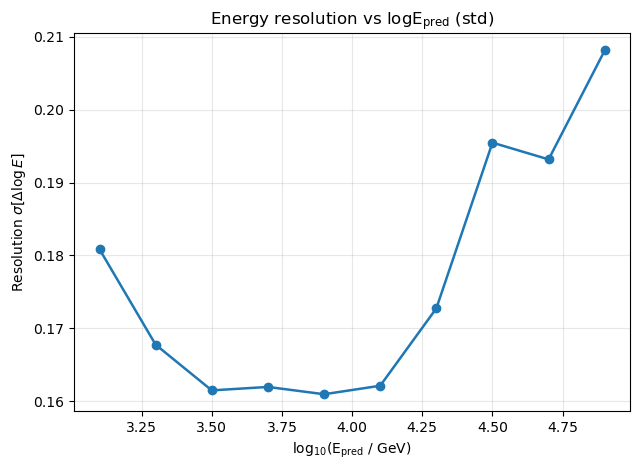

✅ 以预测能量分bin的分布图已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/true_dist_in_pred_bins_truelogE_weighted_20260308_021026.png


[{'bin': 0,
  'logE_pred_lo': 3.0,
  'logE_pred_hi': 3.2,
  'N_eff': 53658.70851441396,
  'mu': 3.0186264848898965,
  'sigma': 0.1875792047511117,
  'ref': 3.1},
 {'bin': 1,
  'logE_pred_lo': 3.2,
  'logE_pred_hi': 3.4,
  'N_eff': 41636.970792387474,
  'mu': 3.206912111067789,
  'sigma': 0.17793902365137756,
  'ref': 3.3},
 {'bin': 2,
  'logE_pred_lo': 3.4,
  'logE_pred_hi': 3.6,
  'N_eff': 27466.86463172269,
  'mu': 3.4151295105618575,
  'sigma': 0.1724801631179134,
  'ref': 3.5},
 {'bin': 3,
  'logE_pred_lo': 3.6,
  'logE_pred_hi': 3.8,
  'N_eff': 14618.089006940882,
  'mu': 3.61477168462433,
  'sigma': 0.17124653062418238,
  'ref': 3.7},
 {'bin': 4,
  'logE_pred_lo': 3.8,
  'logE_pred_hi': 4.0,
  'N_eff': 7997.254252904833,
  'mu': 3.8105371241206263,
  'sigma': 0.17036564183547961,
  'ref': 3.9},
 {'bin': 5,
  'logE_pred_lo': 4.0,
  'logE_pred_hi': 4.2,
  'N_eff': 4673.227837719449,
  'mu': 4.006796278308129,
  'sigma': 0.17046039770462798,
  'ref': 4.1},
 {'bin': 6,
  'logE_pred_l

In [37]:
import numpy as np
data = np.load("/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig/preds.npz")

logE_pred = data["logE_pred"]
logE_true = data["logE_true"]
mc_weight = data["mc_weight"]

res = plot_resolution_vs_pred_energy(
    logE_pred=logE_pred,
    logE_true=logE_true,
    weights=mc_weight,
    pred_range=(3.0, 5.0),
    pred_step=0.2,
    method="std",   # 推荐
    min_events=30,
    out_path="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/resolution_vs_pred_std.png",
)

plot_true_distributions_in_pred_bins(
        true_logE=logE_true,
        pred_logE=logE_pred,
        weights=mc_weight,                    # ⭐ 新增
        Emin=1e3,
        Emax=1e5,
        nbins_pred=10,
        bins_x=60,
        use_delta=False,
        save_name=None,
        out_dir="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only"
)

✅ 已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/resolution_vs_pred_q68.png


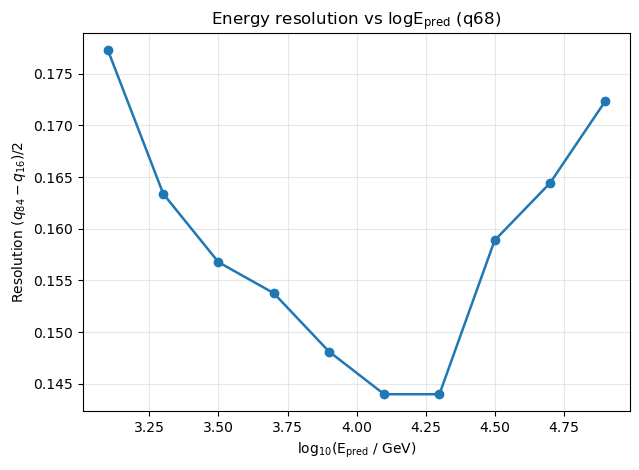

✅ 68%加权分布图已保存到: /home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/true_dist_in_pred_bins_truelogE_contain68_weighted_20260308_021030.png


[{'bin': 0,
  'logE_pred_lo': 3.0,
  'logE_pred_hi': 3.2,
  'N_eff': 53658.70851441396,
  'mu': 3.020702698034384,
  'sigma': 0.18315239423642593,
  'q16': 2.8371869613774527,
  'q84': 3.2034917498503046,
  'ref': 3.1},
 {'bin': 1,
  'logE_pred_lo': 3.2,
  'logE_pred_hi': 3.4,
  'N_eff': 41636.970792387474,
  'mu': 3.2081986136029945,
  'sigma': 0.17360987619944024,
  'q16': 3.0340168032127433,
  'q84': 3.3812365556116237,
  'ref': 3.3},
 {'bin': 2,
  'logE_pred_lo': 3.4,
  'logE_pred_hi': 3.6,
  'N_eff': 27466.86463172269,
  'mu': 3.4151966630271744,
  'sigma': 0.16888230548366812,
  'q16': 3.248023300520238,
  'q84': 3.585787911487574,
  'ref': 3.5},
 {'bin': 3,
  'logE_pred_lo': 3.6,
  'logE_pred_hi': 3.8,
  'N_eff': 14618.089006940882,
  'mu': 3.6178944824847368,
  'sigma': 0.16475887447396098,
  'q16': 3.451025609163559,
  'q84': 3.780543358111481,
  'ref': 3.7},
 {'bin': 4,
  'logE_pred_lo': 3.8,
  'logE_pred_hi': 4.0,
  'N_eff': 7997.254252904833,
  'mu': 3.81433718029447,
  'si

In [38]:
import numpy as np
data = np.load("/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig/preds.npz")

logE_pred = data["logE_pred"]
logE_true = data["logE_true"]
mc_weight = data["mc_weight"]

res = plot_resolution_vs_pred_energy(
    logE_pred=logE_pred,
    logE_true=logE_true,
    weights=mc_weight,
    pred_range=(3.0, 5.0),
    pred_step=0.2,
    method="q68",   # 推荐
    min_events=30,
    out_path="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only/resolution_vs_pred_q68.png",
)

plot_true_distributions_in_pred_bins68(
        true_logE=logE_true,
        pred_logE=logE_pred,
        weights=mc_weight,                    # ⭐ 新增
        Emin=1e3,
        Emax=1e5,
        nbins_pred=10,
        bins_x=60,
        use_delta=False,
        save_name=None,
        out_dir="/home/server/projects/energy_reconstruction/runs/ture_in_pred_2700/fig_eval_only"
)

In [1]:
# 用2707 theta版本评估pure noise数据
import os
import json
import copy
import numpy as np
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

def main(run_dir, overrides=None, out_dir_name="fig_eval_only"):
    config_path = os.path.join(run_dir, "config.json")
    ckpt_path = os.path.join(run_dir, "checkpoints", "best_model.pt")

    with open(config_path, "r") as f:
        args = json.load(f)

    # ===== 用 overrides 覆盖 config =====
    if overrides is not None:
        args = copy.deepcopy(args)
        args.update(overrides)

    print(f"📦 使用配置文件: {config_path}")
    print(f"📦 加载模型: {ckpt_path}")

    if overrides:
        print("🛠️ 本次评估覆盖的配置:")
        for k, v in overrides.items():
            print(f"   {k}: {v}")

    utils.check_gpu_status()

    # ===== ROOT 文件 =====
    root_path = args["root_path"]
    files = sorted(os.listdir(root_path))
    files = [os.path.join(root_path, f) for f in files]
    root_files = files[: args["n_files"]]

    print(f"📂 root_path = {root_path}")
    print(f"📂 使用文件数 = {len(root_files)}")

    # ===== test split =====
    # 如果你换了新数据做泛化测试，这个 split 只是对“新数据集内部”做划分
    # 如果你想评估整个新数据集，也可以直接 test_files = root_files
    _, test_files = train_test_split(
        root_files,
        test_size=args["test_size"],
        random_state=args["seed"]
    )

    print(f"📂 test_files = {len(test_files)}")

    # ===== cuts =====
    cuts = dict(
        Emin=args["Emin"],
        Emax=args["Emax"],
        pinc_max=args["pinc_max"],
        dcedge_min=args["dcedge_min"],
        dangle_max_rad=args["dangle_max_deg"] * np.pi / 180.0,
        theta_max_rad=args["theta_max_deg"] * np.pi / 180.0,
        use_core_box=args["use_core_box"],
        core_box=tuple(args["core_box"]),
        vqsamp_ratio_min=args["vqsamp_ratio_min"],
    )

    print("✂️ cuts =")
    for k, v in cuts.items():
        print(f"   {k}: {v}")

    # ===== dataset =====
    processing_conditions = [
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
        {"subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
    ]

    test_dataset = ParticleDataset(
        root_files=test_files,
        branches=["vx", "vy", "vt", "vq"],
        target_branch=["mc_energy"],
        processing_conditions=processing_conditions,
        max_points=args["max_points"],
        cuts=cuts,
        norm_mode=args["norm_mode"],
        sample_mode=args["sample_mode"],
        io_workers=args["io_workers"],
        compute_scaler=False,
        seed=args["seed"],
        verbose=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=args["batch_size"],
        shuffle=False,
        num_workers=args["num_workers"],
        pin_memory=args["pin_memory"]
    )

    # ===== model =====
    model = ParticleNetRegressor(
        input_dims=2,
        conv_params=[
            (16, (64, 64, 64)),
            (16, (128, 128, 128)),
            (16, (256, 256, 256))
        ],
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True,
        theta_embed_dim=args["theta_embed_dim"],
        theta_embed_dropout=args["theta_embed_dropout"],
    )

    # ===== 评估 =====
    out_dir = os.path.join(run_dir, out_dir_name)
    os.makedirs(out_dir, exist_ok=True)

    evaluate_model(
        model,
        test_loader,
        checkpoint_path=ckpt_path,
        out_dir=out_dir,
        space=args["eval_space"],
        save_arrays=True,
    )

    print("✅ 评估完成")
    print(f"📊 图像输出: {out_dir}")

In [ ]:
# 跑纯噪声eval
run_dir = "/home/server/projects/energy_reconstruction/runs/theta_embed_2707"

overrides = {
    "root_path": "/home/server/mydisk/WCDA_purenoise",
}

main(run_dir, overrides=overrides, out_dir_name="fig_eval_pure_noise")

📦 使用配置文件: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/config.json
📦 加载模型: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/checkpoints/best_model.pt
🛠️ 本次评估覆盖的配置:
   root_path: /home/server/mydisk/WCDA_purenoise
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
📂 root_path = /home/server/mydisk/WCDA_purenoise
📂 使用文件数 = 10000
📂 test_files = 2000
✂️ cuts =
   Emin: 100.0
   Emax: None
   pinc_max: 1.1
   dcedge_min: 20.0
   dangle_max_rad: 0.05235987755982988
   theta_max_rad: 0.5235987755982988
   use_core_box: False
   core_box: (-130.0, 130.0, -110.0, 110.0)
   vqsamp_ratio_min: None
使用设备: cuda


/home/server/projects/energy_reconstruction/src/theta/evaluate_theta.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_locati

✅ 成功加载模型权重: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/checkpoints/best_model.pt

=== 模型评估结果（overall）===
[log][unweighted]   bias=0.2403, sigma=0.7114, rmse=0.7508
[log][mc_weighted] bias=0.2847, sigma=0.6223, rmse=0.6843
[lin][unweighted]  rel_bias=4.7690, rel_sigma=16.6489
[lin][mc_weighted] rel_bias=4.8363, rel_sigma=16.5975
[log]             R²=-0.9148
✅ Resolution 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pure_noise/resolution_20260308_152831.png
✅ Energy response heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pure_noise/pred_vs_true_heatmap_20260308_152831.png
✅ Bias 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pure_noise/bias_20260308_152832.png
✅ log RMS error 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pure_noise/logRMS_20260308_152832.png
✅ 以预测能量分bin的分布图已保存到: /home/server/projects/energy_reconstr

In [5]:
# 评估扩大dcangle
run_dir = "/home/server/projects/energy_reconstruction/runs/theta_embed_2707"

overrides = {
      "dangle_max_deg": 50.0,
}

main(run_dir, overrides=overrides, out_dir_name="fig_eval_lesscut")

📦 使用配置文件: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/config.json
📦 加载模型: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/checkpoints/best_model.pt
🛠️ 本次评估覆盖的配置:
   dangle_max_deg: 50.0
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
📂 root_path = /home/server/mydisk/WCDA_simulation
📂 使用文件数 = 10000
📂 test_files = 2000
✂️ cuts =
   Emin: 100.0
   Emax: None
   pinc_max: 1.1
   dcedge_min: 20.0
   dangle_max_rad: 0.8726646259971648
   theta_max_rad: 0.5235987755982988
   use_core_box: False
   core_box: (-130.0, 130.0, -110.0, 110.0)
   vqsamp_ratio_min: None
使用设备: cuda


/home/server/projects/energy_reconstruction/src/theta/evaluate_theta.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_locati

✅ 成功加载模型权重: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/checkpoints/best_model.pt

=== 模型评估结果（overall）===
[log][unweighted]   bias=0.0305, sigma=0.3314, rmse=0.3328
[log][mc_weighted] bias=0.0319, sigma=0.3152, rmse=0.3168
[lin][unweighted]  rel_bias=0.9201, rel_sigma=16.2354
[lin][mc_weighted] rel_bias=0.9411, rel_sigma=16.5154
[log]             R²=0.7494
✅ Resolution 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_lesscut/resolution_20260308_180054.png
✅ Energy response heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_lesscut/pred_vs_true_heatmap_20260308_180055.png
✅ Bias 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_lesscut/bias_20260308_180055.png
✅ log RMS error 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_lesscut/logRMS_20260308_180056.png
✅ 以预测能量分bin的分布图已保存到: /home/server/projects/energy_reconstruction/runs/t

In [4]:
# 评估扩大pincness
run_dir = "/home/server/projects/energy_reconstruction/runs/theta_embed_2707"

overrides = {
      "pincness": 50.0,
}

main(run_dir, overrides=overrides, out_dir_name="fig_eval_pincness50")

📦 使用配置文件: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/config.json
📦 加载模型: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/checkpoints/best_model.pt
🛠️ 本次评估覆盖的配置:
   pincness: 50.0
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
📂 root_path = /home/server/mydisk/WCDA_simulation
📂 使用文件数 = 10000
📂 test_files = 2000
✂️ cuts =
   Emin: 100.0
   Emax: None
   pinc_max: 1.1
   dcedge_min: 20.0
   dangle_max_rad: 0.05235987755982988
   theta_max_rad: 0.5235987755982988
   use_core_box: False
   core_box: (-130.0, 130.0, -110.0, 110.0)
   vqsamp_ratio_min: None
使用设备: cuda


/home/server/projects/energy_reconstruction/src/theta/evaluate_theta.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_locati

✅ 成功加载模型权重: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/checkpoints/best_model.pt

=== 模型评估结果（overall）===
[log][unweighted]   bias=0.0119, sigma=0.2032, rmse=0.2036
[log][mc_weighted] bias=0.0063, sigma=0.2055, rmse=0.2056
[lin][unweighted]  rel_bias=0.1491, rel_sigma=1.0201
[lin][mc_weighted] rel_bias=0.1376, rel_sigma=1.0204
[log]             R²=0.8728
✅ Resolution 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pincness50/resolution_20260310_130759.png
✅ Energy response heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pincness50/pred_vs_true_heatmap_20260310_130759.png
✅ Bias 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pincness50/bias_20260310_130800.png
✅ log RMS error 图像已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_pincness50/logRMS_20260310_130800.png
✅ 以预测能量分bin的分布图已保存到: /home/server/projects/energy_reconstruct

In [4]:
# 针对1TeV-100TeV训练的模型话diff图
import numpy as np
data = np.load("/home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/preds.npz")
logE_true = data["logE_true"]
logE_pred = data["logE_pred"]
mc_weight = data["mc_weight"]

plot_pred_vs_logdiff_heatmap(
    true=logE_true,
    pred=logE_pred,
    weights=mc_weight,
    bins=(120, 100),
    diff_range=(-1.2, 1.2),
    out_dir="/home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only",
    space="log",
)

✅ Pred vs log-diff heatmap 已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/pred_vs_logdiff_heatmap_weighted_20260309_010000.png


✅ 已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/resolution_vs_pred_std.png


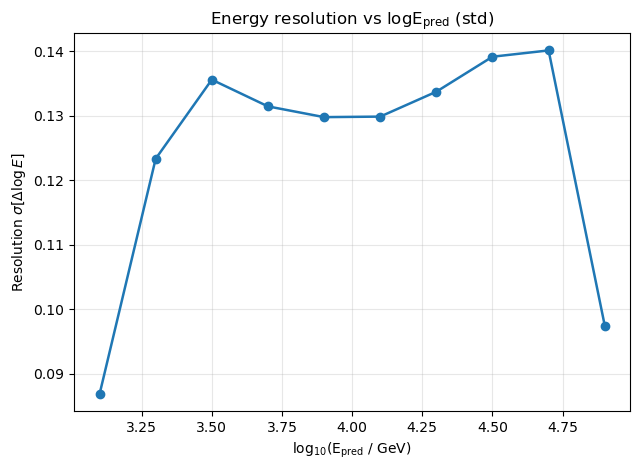

✅ 以预测能量分bin的分布图已保存到: /home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/true_dist_in_pred_bins_truelogE_weighted_20260309_010455.png


[{'bin': 0,
  'logE_pred_lo': 3.0,
  'logE_pred_hi': 3.2,
  'N_eff': 49117.45832931531,
  'mu': 3.1132412063318555,
  'sigma': 0.08964605824041044,
  'ref': 3.1},
 {'bin': 1,
  'logE_pred_lo': 3.2,
  'logE_pred_hi': 3.4,
  'N_eff': 58887.793853764815,
  'mu': 3.240429452341911,
  'sigma': 0.135587724793597,
  'ref': 3.3},
 {'bin': 2,
  'logE_pred_lo': 3.4,
  'logE_pred_hi': 3.6,
  'N_eff': 28357.972341533998,
  'mu': 3.448356237857097,
  'sigma': 0.14797216987884082,
  'ref': 3.5},
 {'bin': 3,
  'logE_pred_lo': 3.6,
  'logE_pred_hi': 3.8,
  'N_eff': 15445.374218408444,
  'mu': 3.647203418613318,
  'sigma': 0.14285178237992135,
  'ref': 3.7},
 {'bin': 4,
  'logE_pred_lo': 3.8,
  'logE_pred_hi': 4.0,
  'N_eff': 8911.048828178617,
  'mu': 3.8356895512614093,
  'sigma': 0.1407065611305707,
  'ref': 3.9},
 {'bin': 5,
  'logE_pred_lo': 4.0,
  'logE_pred_hi': 4.2,
  'N_eff': 5096.441225590829,
  'mu': 4.0311063094445005,
  'sigma': 0.14095377234920492,
  'ref': 4.1},
 {'bin': 6,
  'logE_pred_

In [10]:
# 画1TeV-100TeV的分bin图和resolution
res = plot_resolution_vs_pred_energy(
    logE_pred=logE_pred,
    logE_true=logE_true,
    weights=mc_weight,
    pred_range=(3.0, 5.0),
    pred_step=0.2,
    method="std",   # 推荐
    min_events=30,
    out_path="/home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only/resolution_vs_pred_std.png",
)

plot_true_distributions_in_pred_bins(
        true_logE=logE_true,
        pred_logE=logE_pred,
        weights=mc_weight,                    # ⭐ 新增
        Emin=1e3,
        Emax=1e5,
        nbins_pred=10,
        bins_x=60,
        use_delta=False,
        save_name=None,
        out_dir="/home/server/projects/energy_reconstruction/runs/theta_embed_2709/fig_eval_only"
)